# Notebook 2: Heart Disease Prediction
**Dataset**: Heart Failure Prediction Dataset (Kaggle)
**Target**: HeartDisease (0 = No, 1 = Yes)
**Model**: Random Forest Classifier + GridSearchCV Tuning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import joblib
import warnings
warnings.filterwarnings('ignore')
print('Libraries loaded')

Libraries loaded


## Step 1: Load Data

In [2]:
df = pd.read_csv('../datasets/heart.csv')
print('Shape:', df.shape)
df.head()

Shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
print(df.dtypes)
print('\nMissing values:\n', df.isnull().sum())
print('\nClass distribution:\n', df['HeartDisease'].value_counts())

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

Missing values:
 Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Class distribution:
 HeartDisease
1    508
0    410
Name: count, dtype: int64


## Step 2: EDA

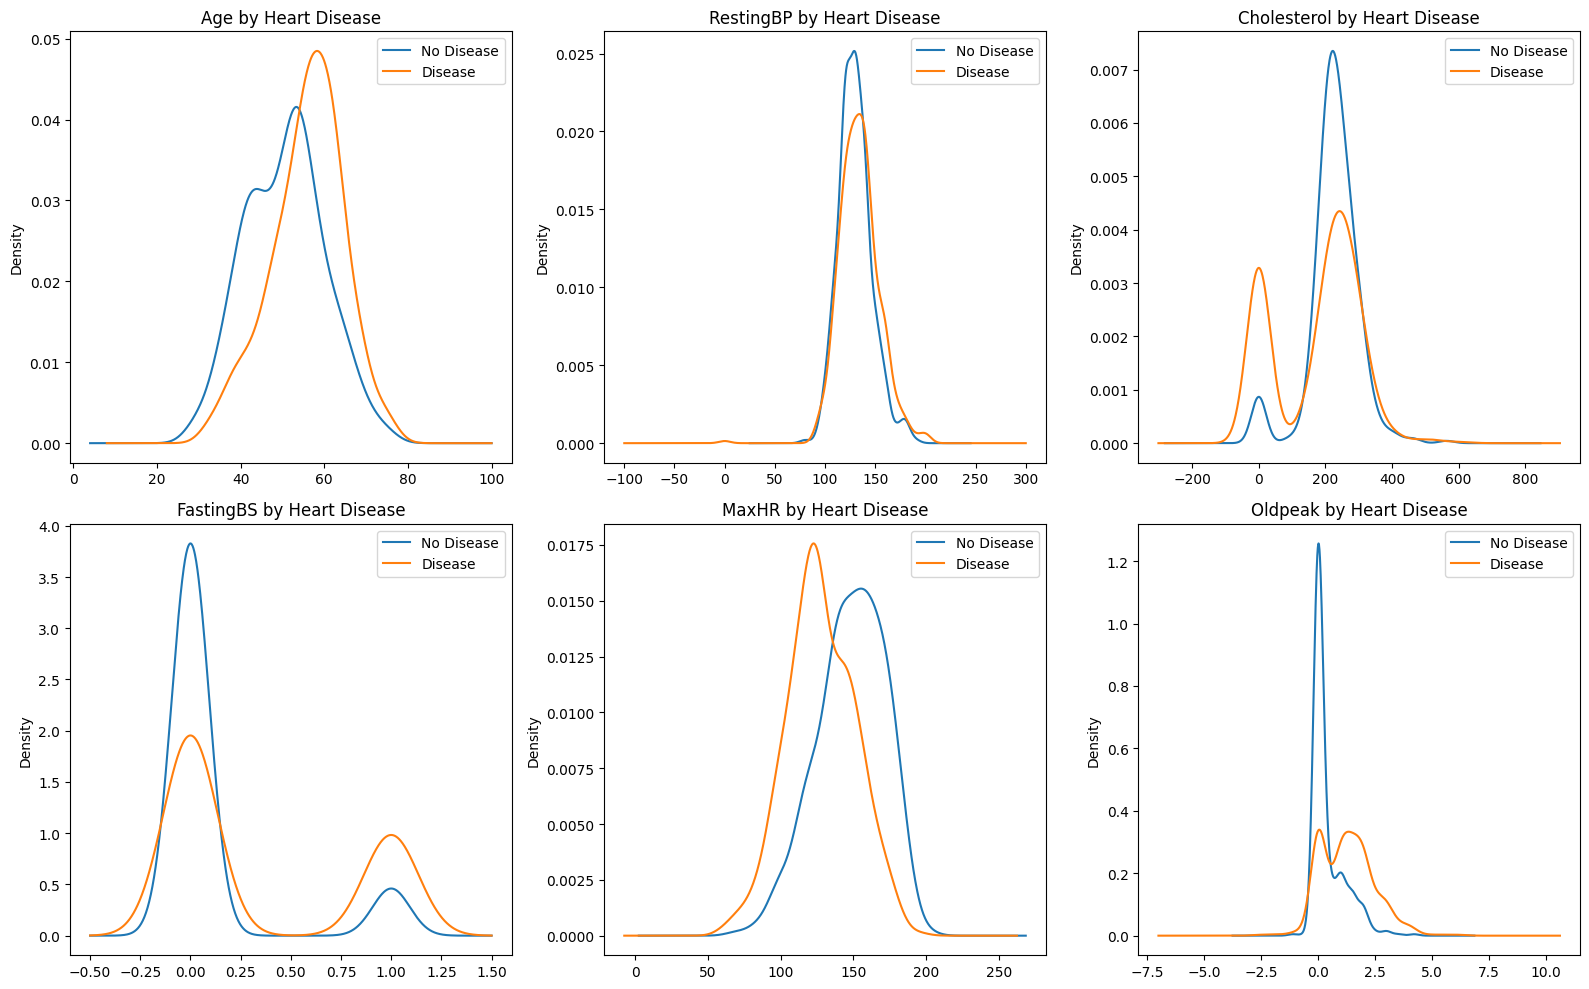

In [4]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = [c for c in df.select_dtypes(include=np.number).columns if c != 'HeartDisease']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for i, col in enumerate(num_cols[:6]):
    ax = axes[i//3][i%3]
    df.groupby('HeartDisease')[col].plot(kind='kde', ax=ax)
    ax.set_title(f'{col} by Heart Disease')
    ax.legend(['No Disease','Disease'])
plt.tight_layout()
plt.show()

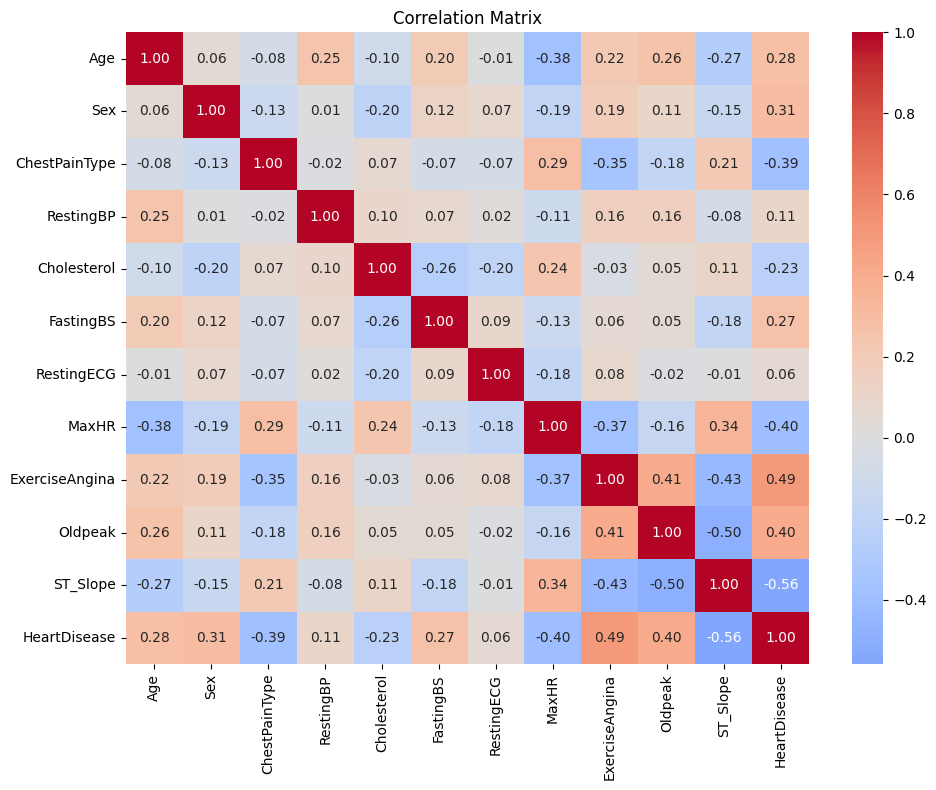

In [5]:
plt.figure(figsize=(10, 8))
df_enc = df.copy()
for col in cat_cols:
    df_enc[col] = LabelEncoder().fit_transform(df_enc[col])
sns.heatmap(df_enc.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## Step 3: Preprocessing

In [6]:
le = LabelEncoder()
for col in cat_cols:
    df_enc[col] = le.fit_transform(df[col])
X = df_enc.drop('HeartDisease', axis=1)
y = df_enc['HeartDisease']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (734, 11), Test: (184, 11)


## Step 4: Baseline Model

In [7]:
baseline = RandomForestClassifier(n_estimators=100, random_state=42)
baseline.fit(X_train, y_train)
baseline_acc = accuracy_score(y_test, baseline.predict(X_test))
baseline_auc = roc_auc_score(y_test, baseline.predict_proba(X_test)[:,1])
print(f'Baseline Accuracy : {baseline_acc:.4f}')
print(f'Baseline ROC-AUC  : {baseline_auc:.4f}')

Baseline Accuracy : 0.8750
Baseline ROC-AUC  : 0.9228


## Step 5: Hyperparameter Tuning (GridSearchCV)

In [8]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=5, scoring='roc_auc',
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)
print('Best Parameters:', grid_search.best_params_)
print('Best CV ROC-AUC:', f'{grid_search.best_score_:.4f}')

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'max_depth': 8, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}
Best CV ROC-AUC: 0.9325


## Step 6: Tuned Model Evaluation

In [9]:
model = grid_search.best_estimator_
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]
tuned_acc = accuracy_score(y_test, y_pred)
tuned_auc = roc_auc_score(y_test, y_prob)
print(f'Tuned Accuracy : {tuned_acc:.4f}  (Baseline: {baseline_acc:.4f})  Gain: {tuned_acc - baseline_acc:+.4f}')
print(f'Tuned ROC-AUC  : {tuned_auc:.4f}  (Baseline: {baseline_auc:.4f})  Gain: {tuned_auc - baseline_auc:+.4f}')
print('\nClassification Report:\n', classification_report(y_test, y_pred, target_names=['No Disease','Heart Disease']))

Tuned Accuracy : 0.8913  (Baseline: 0.8750)  Gain: +0.0163
Tuned ROC-AUC  : 0.9274  (Baseline: 0.9228)  Gain: +0.0047

Classification Report:
                precision    recall  f1-score   support

   No Disease       0.91      0.84      0.87        82
Heart Disease       0.88      0.93      0.90       102

     accuracy                           0.89       184
    macro avg       0.89      0.89      0.89       184
 weighted avg       0.89      0.89      0.89       184



In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Disease','Disease'], yticklabels=['No Disease','Disease'])
axes[0].set_title('Confusion Matrix (Tuned)')
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='crimson', lw=2, label=f'Tuned AUC={tuned_auc:.2f}')
fpr_b, tpr_b, _ = roc_curve(y_test, baseline.predict_proba(X_test)[:,1])
axes[1].plot(fpr_b, tpr_b, color='gray', lw=1.5, linestyle='--', label=f'Baseline AUC={baseline_auc:.2f}')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_title('ROC Curve: Baseline vs Tuned')
axes[1].legend()
x = np.arange(2)
axes[2].bar(x-0.2, [baseline_acc, baseline_auc], 0.4, label='Baseline', color='#95a5a6')
axes[2].bar(x+0.2, [tuned_acc, tuned_auc], 0.4, label='Tuned', color='crimson')
axes[2].set_xticks(x)
axes[2].set_xticklabels(['Accuracy','ROC-AUC'])
axes[2].set_ylim(0.5, 1.0)
axes[2].set_title('Baseline vs Tuned')
axes[2].legend()
plt.tight_layout()
plt.show()

In [ ]:
feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
feat_imp.plot(kind='bar', color='crimson', edgecolor='white', figsize=(10,4))
plt.title('Feature Importances - Tuned Heart Disease Model')
plt.tight_layout()
plt.show()

## Step 7: Save Model

In [ ]:
joblib.dump(model, '../models/heart_model.pkl')
joblib.dump(scaler, '../models/heart_scaler.pkl')
print('Heart tuned model and scaler saved!')